In [ ]:
## Using data from Sergeev et al. (2025)

## In this notebook we:
## 1. Load the cubes list for TRAPPIST-1e with 0.5 bar surface pressure (by using the first point in the vertical air pressure array)
## 2. Create a global surface temperature map
## 3. Constrain the dayside and take a zonal average for air temperature
## 4. Plot a temperature profile w.r.t altitude
## (4.1. Ignore the interpolation business in the profile, we only care about the shape)


In [2]:
import iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import iris.plot as iplt
import iris.quickplot as qplt
import iris.analysis.cartography
import iris.analysis
import aeolus
import aeolus.coord

In [3]:
p_5 = iris.load('/data/cluster4/jj22956/thunderstruck_files/thunderstruck-hab1_0p5bar-m09.nc?download=1')
p_5

/home/jj22956/.local/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


[<iris 'Cube' of air_pressure / (Pa) (model_level_number: 64; latitude: 144; longitude: 97)>,
<iris 'Cube' of air_temperature / (K) (model_level_number: 63; latitude: 144; longitude: 97)>,
<iris 'Cube' of cloud_ice_mixing_ratio / (kg kg-1) (model_level_number: 64; latitude: 144; longitude: 97)>,
<iris 'Cube' of cloud_liquid_water_mixing_ratio / (kg kg-1) (model_level_number: 64; latitude: 144; longitude: 97)>,
<iris 'Cube' of humidity_mixing_ratio / (kg kg-1) (model_level_number: 64; latitude: 144; longitude: 97)>,
<iris 'Cube' of relative_humidity / (%) (model_level_number: 63; latitude: 144; longitude: 97)>,
<iris 'Cube' of upward_air_velocity / (m s-1) (model_level_number: 63; latitude: 144; longitude: 97)>]

In [ ]:
air_tempp = p_5[6]

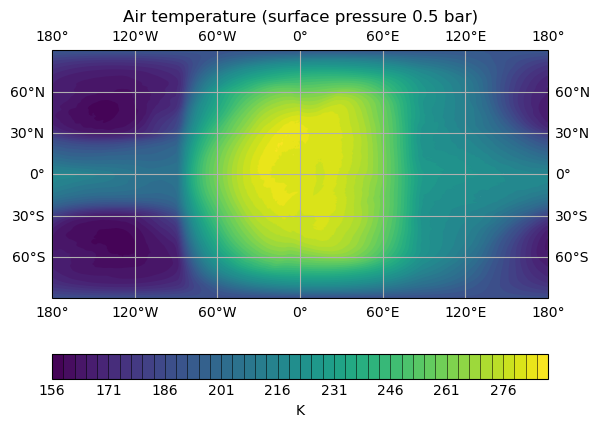

In [3]:
qplt.contourf(air_tempp[0], 50)

plt.gca().gridlines(draw_labels=True)
plt.title('Air temperature (surface pressure 0.5 bar)')
plt.show()

In [4]:
air_tempp_roll = aeolus.coord.roll_cube_pm180(air_tempp, add_shift=0)
air_tempp_roll[0].ndim
air_tempp_roll0 = air_tempp_roll[0]

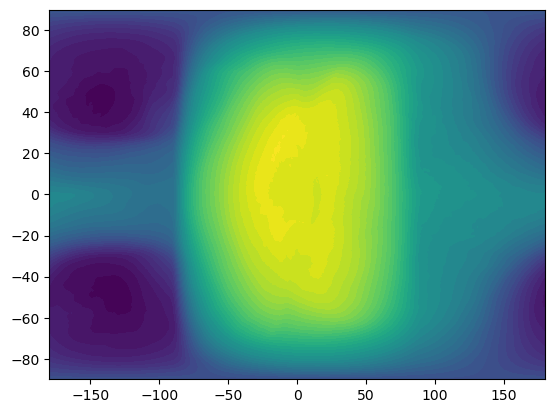

In [5]:
# contour = iplt.contour(air_tempp_roll[0])

x = air_tempp_roll0.coord('longitude').points
y = air_tempp_roll0.coord('latitude').points

data = air_tempp_roll0.data

X, Y = np.meshgrid(x, y)

plt.contourf(x, y, data, 50)

# plt.gca().gridlines(draw_labels=True)
plt.show()

In [6]:
dayside = air_tempp_roll.extract(iris.Constraint(longitude=lambda v:  (-75<= v <= 75)))
# dayside.ndim

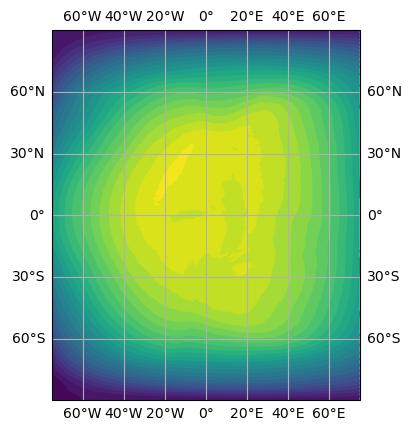

In [7]:
iplt.contourf(dayside[0], 25)

plt.gca().gridlines(draw_labels=True)
plt.show()

In [8]:
# dayside.coord('latitude').guess_bounds()
# dayside.coord('longitude').guess_bounds()
# grid_areas = iris.analysis.cartography.area_weights(dayside)

In [9]:
new_dayside = dayside.collapsed(['longitude', 'latitude'], iris.analysis.MEAN)

/home/jj22956/.local/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'latitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'latitude'. Ignoring bounds.
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'longitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'longitude'. Ignoring bounds.
  warnings.warn(


In [10]:
print(new_dayside.coord('level_height').points)

[   17.91390334    47.77279894    89.569513     143.31122815
   208.99792969   286.6224563    376.19196563   477.70645767
   591.15881888   716.55610402   853.89846005  1003.17857502
  1164.4036874   1337.57383393  1522.68181289  1719.73471578
  1928.73257933  2149.66834879  2382.54911566  2627.37473298
  2884.13855015  3152.84707078  3433.50058883  3726.09212301
  4030.62817695  4347.10955898  4675.52855298  5015.89250765
  5368.20215785  5732.44905258  6108.64127542  6496.78507277
  6896.88816076  7308.99389681  7733.16731697  8169.54988394
  8618.34295235  9079.87023288  9554.60277785 10043.19352013
 10546.54524876 11065.86939857 11602.74851427 12159.20569571
 12737.81005192 13341.76562044 13975.04437905 14642.47406277
 15349.90828655 16104.35588255]


In [11]:
sample_points = [('level_height', np.linspace(400, 1250, 10))]
new_column = new_dayside.interpolate(sample_points, iris.analysis.Linear())

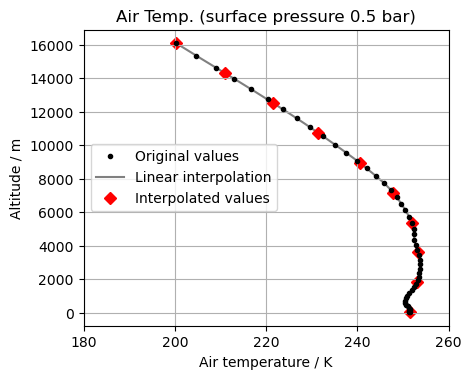

In [12]:
alt_coord = new_dayside.coord("level_height")

# Interpolate the "perfect" linear interpolation. Really this is just
# a high number of interpolation points, in this case 1000 of them.
altitude_points = [
    (
        "level_height",
        np.linspace(min(alt_coord.points), max(alt_coord.points), 1000),
    )
]
scheme = iris.analysis.Linear()
linear_column = new_dayside.interpolate(altitude_points, scheme)

# Now interpolate the data onto 10 evenly spaced altitude levels,
# as we did in the example.
altitude_points = [("level_height", np.linspace(17, 16100, 10))]
scheme = iris.analysis.Linear()
new_column = new_dayside.interpolate(altitude_points, scheme)

plt.figure(figsize=(5, 4), dpi=100)

# Plot the black markers for the original data.
qplt.plot(
    new_dayside,
    marker="o",
    color="black",
    linestyle="",
    markersize=3,
    label="Original values",
    zorder=2,
)

# Plot the gray line to display the linear interpolation.
qplt.plot(
    linear_column,
    color="gray",
    label="Linear interpolation",
    zorder=0,
)

# Plot the red markers for the new data.
qplt.plot(
    new_column,
    marker="D",
    color="red",
    linestyle="",
    label="Interpolated values",
    zorder=1,
)

ax = plt.gca()
# Space the plot such that the labels appear correctly.
plt.subplots_adjust(left=0.17, bottom=0.14)

# Limit the plot to a maximum of 5 ticks.
ax.xaxis.get_major_locator().set_params(nbins=5)

# Prevent matplotlib from using "offset" notation on the xaxis.
ax.xaxis.get_major_formatter().set_useOffset(False)

# Put some space between the line and the axes.
ax.margins(0.05)

# Place gridlines and a legend.
ax.grid()
plt.legend(loc="center left")
plt.title('Air Temp. (surface pressure 0.5 bar)')
plt.ylabel('Altitude / m')
plt.xlim(180, 260)
plt.show()